# 10 - TR vs EN Comparison

Bu notebookta gerçek Kapadokya görüntüleri ile Türkçe ve İngilizce istemlerden üretilen görüntüler karşılaştırılmaktadır.

Karşılaştırmalarda DINOv2 embeddingleri ve Cosine Similarity metriği kullanılmaktadır.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.decomposition import PCA

# Embeddinglerin Yüklenmesi

Bu bölümde gerçek görüntüler ile Türkçe ve İngilizce istemlerden oluşturulan görüntü embeddingleri yüklenmektedir.

In [ ]:
real_embeddings = np.load("../embeddings/chrd_real_embeddings.npy")

tr_embeddings = np.load("../embeddings/sdxl_tr_embeddings.npy")

en_embeddings = np.load("../embeddings/sdxl_en_embeddings.npy")

print(real_embeddings.shape)

print(tr_embeddings.shape)

print(en_embeddings.shape)

(82, 768)
(96, 768)
(96, 768)


# Ortak Görsellerin Seçilmesi

Gerçek veri kümesinde 82 görüntü bulunduğu için karşılaştırmalar ilk 82 üretilmiş görüntü üzerinden gerçekleştirilmektedir.

In [8]:
N = min(
    len(real_embeddings),
    len(tr_embeddings),
    len(en_embeddings)
)

real = real_embeddings[:N]

tr = tr_embeddings[:N]

en = en_embeddings[:N]

print(N)

82


# Cosine Similarity Hesaplanması

Bu bölümde gerçek görüntüler ile Türkçe ve İngilizce istemlerden oluşturulan görüntüler arasındaki benzerlik hesaplanmaktadır.

In [9]:
real_tr = []

real_en = []

tr_en = []

for i in range(N):

    real_tr.append(
        cosine_similarity(
            real[i].reshape(1,-1),
            tr[i].reshape(1,-1)
        )[0][0]
    )

    real_en.append(
        cosine_similarity(
            real[i].reshape(1,-1),
            en[i].reshape(1,-1)
        )[0][0]
    )

    tr_en.append(
        cosine_similarity(
            tr[i].reshape(1,-1),
            en[i].reshape(1,-1)
        )[0][0]
    )

# Ortalama Benzerlik Değerleri

Bu bölümde tüm görüntüler için hesaplanan ortalama cosine similarity değerleri raporlanmaktadır.

In [10]:
print("Real ↔ TR :", np.mean(real_tr))

print("Real ↔ EN :", np.mean(real_en))

print("TR ↔ EN :", np.mean(tr_en))

Real ↔ TR : 0.37631875
Real ↔ EN : 0.43307406
TR ↔ EN : 0.6157543


# Benzerlik Dağılımlarının Görselleştirilmesi

Bu bölümde gerçek görüntüler ile Türkçe ve İngilizce istemlerden oluşturulan görüntüler arasındaki benzerlik dağılımları kutu grafiği (boxplot) ile gösterilmektedir.

Bu görselleştirme, benzerlik skorlarının ortalama değerlerinin yanı sıra dağılımını ve değişkenliğini de ortaya koymaktadır.

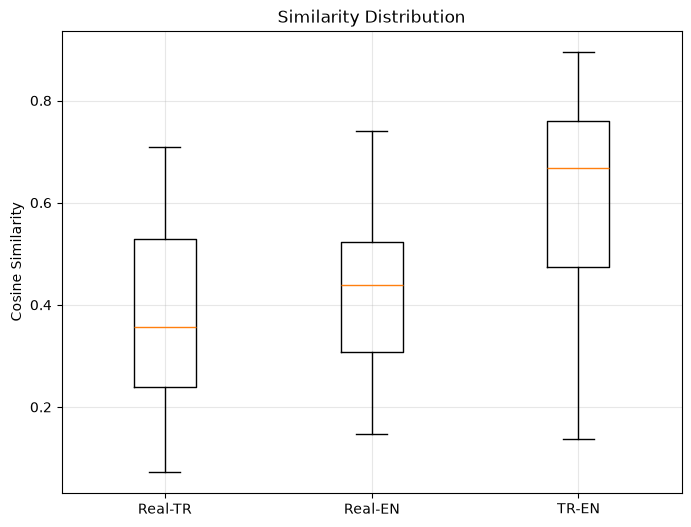

In [12]:
plt.figure(figsize=(8,6))

plt.boxplot(
    [real_tr, real_en, tr_en],
    tick_labels=["Real-TR", "Real-EN", "TR-EN"]
)

plt.ylabel("Cosine Similarity")

plt.title("Similarity Distribution")

plt.grid(alpha=0.3)

plt.show()

# Benzerlik Histogramları

Bu bölümde benzerlik skorlarının dağılımı histogram ile gösterilmektedir.

Histogramlar, farklı istem dillerinin gerçek görüntülere ne kadar yakın sonuçlar ürettiğini görsel olarak karşılaştırmayı kolaylaştırmaktadır.

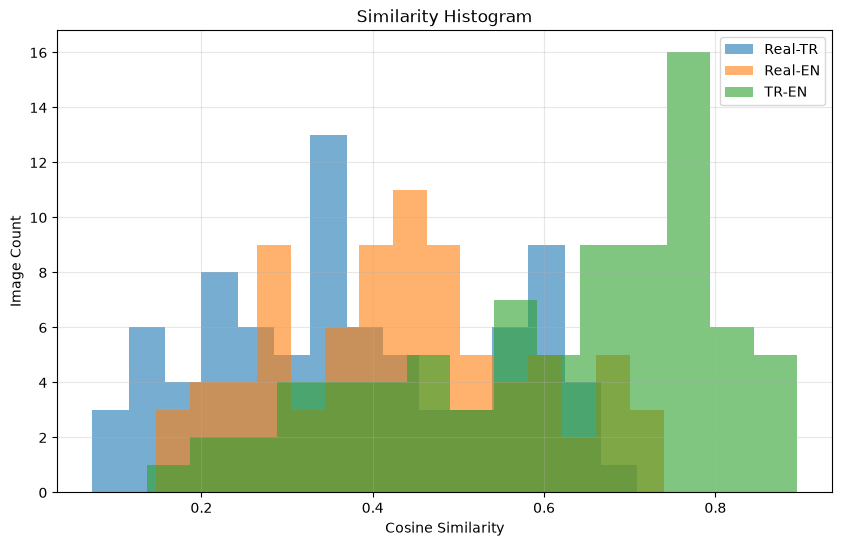

In [13]:
plt.figure(figsize=(10,6))

plt.hist(real_tr, bins=15, alpha=0.6, label="Real-TR")

plt.hist(real_en, bins=15, alpha=0.6, label="Real-EN")

plt.hist(tr_en, bins=15, alpha=0.6, label="TR-EN")

plt.xlabel("Cosine Similarity")

plt.ylabel("Image Count")

plt.title("Similarity Histogram")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Ortalama Benzerlik Karşılaştırması

Bu bölümde üç farklı karşılaştırmanın ortalama benzerlik değerleri sütun grafiği ile gösterilmektedir.

Bu grafik posterde kullanılacak temel sonuçlardan biridir.

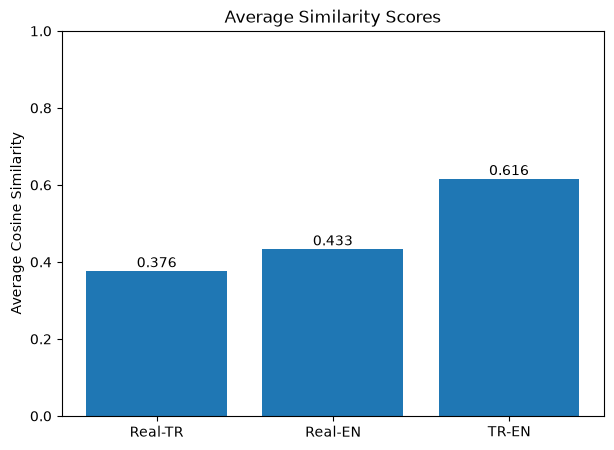

In [14]:
means = [
    np.mean(real_tr),
    np.mean(real_en),
    np.mean(tr_en)
]

labels = [
    "Real-TR",
    "Real-EN",
    "TR-EN"
]

plt.figure(figsize=(7,5))

plt.bar(labels, means)

plt.ylim(0,1)

plt.ylabel("Average Cosine Similarity")

plt.title("Average Similarity Scores")

for i,v in enumerate(means):

    plt.text(i, v+0.01, f"{v:.3f}", ha="center")

plt.show()

# Sonuç Tablosu

Bu bölümde hesaplanan ortalama benzerlik değerleri tablo halinde sunulmaktadır.

In [15]:
results = pd.DataFrame({

    "Comparison":[
        "Real ↔ Turkish",
        "Real ↔ English",
        "Turkish ↔ English"
    ],

    "Average Cosine Similarity":[
        np.mean(real_tr),
        np.mean(real_en),
        np.mean(tr_en)
    ]

})

results

,Comparison,Average Cosine Similarity
0,Real ↔ Turkish,0.376319
1,Real ↔ English,0.433074
2,Turkish ↔ English,0.615754


In [17]:
results.to_csv(
    "../results/similarity_results.csv",
    index=False
)

print("similarity_results.csv kaydedildi.")

similarity_results.csv kaydedildi.
